In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit


In [42]:
df = pd.read_csv("solar_system.csv")

In [3]:
df.shape

(20, 11)

There are 20 rows and 11 columns.

In [5]:
df.head()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [6]:
df.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [7]:
df.columns

Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')

In [18]:
print(df.loc[:, 'Attribute'])

0                  Mass (10^24kg)
1                   Diameter (km)
2                Density (kg/m^3)
3                 Gravity (m/s^2)
4          Escape Velocity (km/s)
5         Rotation Period (hours)
6           Length of Day (hours)
7     Distance from Sun (10^6 km)
8            Perihelion (10^6 km)
9              Aphelion (10^6 km)
10          Orbital Period (days)
11        Orbital Velocity (km/s)
12      Orbital Inclination (deg)
13           Orbital Eccentricity
14       Obliquity to Orbit (deg)
15           Mean Temperature (C)
16        Surface Pressure (bars)
17                Number of Moons
18                   Ring System?
19         Global Magnetic Field?
Name: Attribute, dtype: object


**Perihelion**: point in orbit when Earth is closest to the Sun

**Aphelion**: point in orbit when Earth is furthest from the Sun

**Semi-major axis**: half the longest diameter of an ellipse.

In [45]:
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)
orbital_period = df.iloc[10, 1:].astype(float)

semi_major_axis = (perihelion + aphelion) / 2

semi_major_axis_row = pd.Series(
    ['Semi-Major Axis (AU)'] + list(semi_major_axis),
    index=df.columns
)

df = pd.concat([df, semi_major_axis_row.to_frame().T], ignore_index=True)
print(df.shape)

(21, 11)


In [47]:
print(df)

                      Attribute Mercury    Venus  Earth    Moon   Mars  \
0                Mass (10^24kg)   0.330     4.87   5.97   0.073  0.642   
1                 Diameter (km)    4879    12104  12756    3475   6792   
2              Density (kg/m^3)    5429     5243   5514    3340   3934   
3               Gravity (m/s^2)     3.7      8.9    9.8     1.6    3.7   
4        Escape Velocity (km/s)     4.3     10.4   11.2     2.4    5.0   
5       Rotation Period (hours)  1407.6  -5832.5   23.9   655.7   24.6   
6         Length of Day (hours)  4222.6   2802.0   24.0   708.7   24.7   
7   Distance from Sun (10^6 km)    57.9    108.2  149.6   0.384  228.0   
8          Perihelion (10^6 km)    46.0    107.5  147.1   0.363  206.7   
9            Aphelion (10^6 km)    69.8    108.9  152.1   0.406  249.3   
10        Orbital Period (days)    88.0    224.7  365.2    27.3  687.0   
11      Orbital Velocity (km/s)    47.4     35.0   29.8     1.0   24.1   
12    Orbital Inclination (deg)     7.

In [49]:
df_new = df.iloc[[8, 9, 10, 20], :]
df_new

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9
10,Orbital Period (days),88.0,224.7,365.2,27.3,687.0,4331,10747,30589,59800,90560
20,Semi-Major Axis (AU),57.9,108.2,149.6,0.3845,228.0,778.5,1432.05,2867.05,4515.0,5906.35


In [51]:
df_new.shape
# 4 rows, 11 columns.

(4, 11)

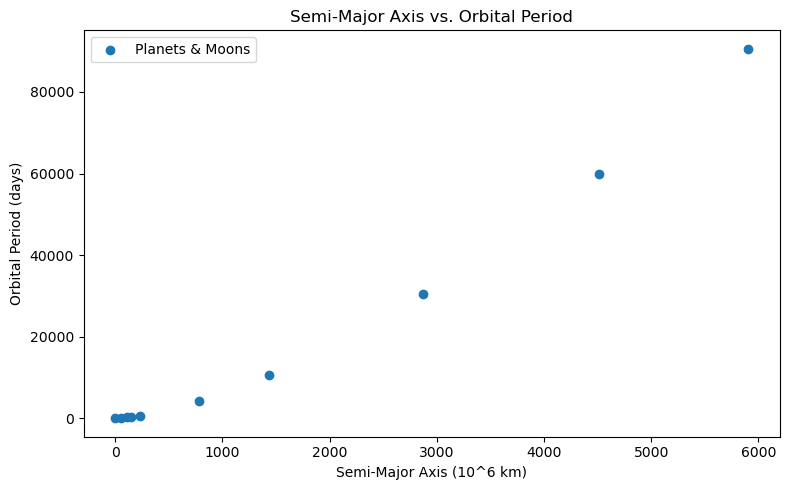

In [59]:
plt.figure(figsize=(8, 5))
plt.scatter(semi_major_axis, orbital_period, label='Planets & Moons')
plt.xlabel('Semi-Major Axis (10^6 km)')
plt.ylabel('Orbital Period (days)')
plt.title('Semi-Major Axis vs. Orbital Period')
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
def keplers_third_law(a,m):
    return m * a ** 1.5

popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period, p0=[1])
m_fit = popt[0]

print(f"Fitted m: {m_fit:.2f}")

Fitted m: 0.20


In [62]:
m_fit = popt[0]

print(f"Fit: T = {m_fit:.2f} * a^1.5")

Fit: T = 0.20 * a^1.5


In [63]:
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(orbital_period) - len(popt)
chi2_reduced = chi2 / dof

print(f"Reduced chi-squared: {chi2_reduced:.2f}")

Reduced chi-squared: 41276.71
